# Quantitative Evaluation: How Close Is Auto-Style to Your Lightroom Edits?

**Goal:** Measure the gap between our pipeline's auto-styled output and your actual Lightroom edits using three complementary metrics:

1. **SSIM** (Structural Similarity) - do the images look structurally alike? Higher = better, 1.0 = identical.
2. **LPIPS** (Learned Perceptual Image Patch Similarity) - does a neural network think they look similar? Lower = better, 0.0 = identical.
3. **Delta E (CIEDE2000)** - are the colors perceptually close? Lower = better. Under 2.0 is generally imperceptible to humans.

This gives us a baseline. Every renderer change, profile tweak, or strength adjustment gets measured against these numbers.

**Depends on:** Pipelines 02-03 (style profiles), `shared.py`

**Runtime:** GPU required (SAM + LPIPS network). ~10 min for 50 images on T4.

In [2]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/photo-style-rl'

!pip install anthropic segment-anything opencv-python-headless kornia lpips scikit-image -q

import shutil
shutil.copy(f'{PROJECT}/src/shared.py', '/content/shared.py')

import os, json, torch, cv2, time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from google.colab import userdata
from anthropic import Anthropic
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from skimage.metrics import structural_similarity as ssim
from skimage.color import rgb2lab, deltaE_ciede2000
import lpips

from shared import (
    PROJECT, RAW_DIR, EDITED_DIR, CHECKPOINTS_DIR,
    pair_files, resize_for_sam, extract_json, image_to_base64,
    DeterministicRenderer, segment_and_label, apply_regional_edits,
    feather_mask, load_style_profile, validate_region_edit,
    detect_skin_mask, AVAILABLE_REGIONS
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
client = Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

# Load SAM
SAM_CHECKPOINT = f'{CHECKPOINTS_DIR}/sam_vit_h_4b8939.pth'
sam = sam_model_registry['vit_h'](checkpoint=SAM_CHECKPOINT).to(device)
auto_generator = SamAutomaticMaskGenerator(
    sam, points_per_side=32, pred_iou_thresh=0.86,
    stability_score_thresh=0.92, min_mask_region_area=0,
)

# Load both style profiles
advanced_profile = load_style_profile('simon_advanced_color_profile.json')
math_profile = load_style_profile('simon_math_profile.json')

# Mask label cache
CACHE_PATH = f'{CHECKPOINTS_DIR}/mask_labels_cache.json'
mask_cache = json.loads(open(CACHE_PATH).read()) if os.path.exists(CACHE_PATH) else {}

# LPIPS network (AlexNet backbone - fast and well-correlated with human perception)
lpips_fn = lpips.LPIPS(net='alex').to(device)

renderer = DeterministicRenderer()
pairs = pair_files()

print(f"Ready: {len(pairs)} pairs, device={device}")
print(f"Advanced profile regions: {list(advanced_profile.keys())}")
print(f"Math profile regions: {list(math_profile.keys())}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.1/472.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 121.4 MB/s eta 0:00:00
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 186MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Ready: 287 pairs, device=cuda
Advanced profile regions: ['ground', 'subject', 'background', 'highlight_area', 'clothing', 'sky', 'building', 'shadow_area', 'face', 'foliage', 'water']
Math profile regions: ['ground', 'subject', 'background', 'highlight_area', 'clothing', 'sky', 'building', 'shadow_area', 'face', 'hair', 'foliage', 'water']


In [3]:
# Metric functions
def compute_metrics(result_pil, target_pil):
    """Compute SSIM, LPIPS, and Delta E between pipeline output and your Lightroom edit.

    SSIM: structural similarity in [0, 1]. Measures luminance, contrast, and structure.
    LPIPS: perceptual distance via a pretrained AlexNet. Correlates well with human judgment.
    Delta E: CIEDE2000 color difference in Lab space. Under 2.0 is imperceptible to most people.
    """
    # Resize target to match result (they may differ slightly due to resize_for_sam)
    target_resized = target_pil.resize(result_pil.size, Image.LANCZOS)

    result_np = np.array(result_pil).astype(np.float32) / 255.0
    target_np = np.array(target_resized).astype(np.float32) / 255.0

    # SSIM - computed on the full RGB image, channel_axis=2 means color is the 3rd dimension
    ssim_val = ssim(result_np, target_np, channel_axis=2, data_range=1.0)

    # LPIPS - needs tensors in [-1, 1] range with shape [1, 3, H, W]
    result_tensor = torch.from_numpy(result_np).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1
    target_tensor = torch.from_numpy(target_np).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1
    with torch.no_grad():
        lpips_val = lpips_fn(result_tensor, target_tensor).item()

    # Delta E - convert both to Lab color space first, then compute CIEDE2000
    # Lab is designed so that equal numerical distances correspond to equal perceived differences
    result_lab = rgb2lab(result_np)
    target_lab = rgb2lab(target_np)
    delta_e = np.mean(deltaE_ciede2000(result_lab, target_lab))

    return {
        'ssim': round(ssim_val, 4),
        'lpips': round(lpips_val, 4),
        'delta_e': round(delta_e, 2),
    }


def auto_style_image(pil_img, image_id=None):
    """Run the auto-style pipeline on a single image. Returns the styled PIL image.
    This mirrors run_inference() from NB04 but without text overrides."""
    segments = segment_and_label(
        pil_img, auto_generator, client,
        cache=mask_cache, image_id=image_id,
    )

    # Build regional edits from matched profiles
    profile_edits = []
    applied = {}
    seen = set()
    for seg in segments:
        label = seg['label']
        if label in seen:
            continue
        seen.add(label)
        if label in advanced_profile:
            profile_edits.append({'region': label, 'params': advanced_profile[label]})
            applied[label] = 'advanced'
        elif label in math_profile:
            region_params = math_profile[label].get('parameters', {})
            if region_params:
                profile_edits.append({'region': label, 'params': region_params})
                applied[label] = 'math'

    result = apply_regional_edits(pil_img, segments, profile_edits, renderer, strength=0.6)
    return result, segments, applied


print("Metric functions ready.")

Metric functions ready.


## Run Evaluation

We auto-style a sample of your images and compare each result against your Lightroom edit. The metrics tell us how close we are overall, and which images/regions are failing.

In [4]:
# Evaluate on a sample (50 images covers good variety without taking too long)
eval_sample = min(len(pairs), 50)
eval_indices = np.linspace(0, len(pairs) - 1, eval_sample, dtype=int)

all_metrics = []
timing = []

print(f"Evaluating {eval_sample} images...\n")

for count, idx in enumerate(eval_indices):
    raw_f, edited_f = pairs[idx]
    t0 = time.time()

    try:
        raw_img = Image.open(os.path.join(RAW_DIR, raw_f)).convert('RGB')
        raw_resized = resize_for_sam(raw_img)
        target_img = Image.open(os.path.join(EDITED_DIR, edited_f)).convert('RGB')

        result, segs, applied = auto_style_image(raw_resized, image_id=raw_f)
        metrics = compute_metrics(result, target_img)

        metrics['image'] = raw_f
        metrics['regions'] = list(applied.keys())
        metrics['region_sources'] = applied
        all_metrics.append(metrics)

        elapsed = time.time() - t0
        timing.append(elapsed)

        # Progress update every 10 images
        if (count + 1) % 10 == 0:
            avg_ssim = np.mean([m['ssim'] for m in all_metrics])
            print(f"  [{count+1}/{eval_sample}] avg SSIM={avg_ssim:.4f}, "
                  f"last={raw_f} ({elapsed:.1f}s)")

    except Exception as e:
        print(f"  Error on {raw_f}: {e}")

# Save mask cache (any new LLM labels get persisted)
with open(CACHE_PATH, 'w') as f:
    json.dump(mask_cache, f, indent=2)

print(f"\nDone. Evaluated {len(all_metrics)} images in {sum(timing):.0f}s "
      f"({np.mean(timing):.1f}s avg per image)")

Evaluating 50 images...

  [10/50] avg SSIM=0.9307, last=raw_053.jpg (11.3s)
  [20/50] avg SSIM=0.9193, last=raw_111.jpg (11.6s)
  [30/50] avg SSIM=0.9256, last=raw_170.jpg (10.8s)
  [40/50] avg SSIM=0.9155, last=raw_228.jpg (12.2s)
  [50/50] avg SSIM=0.9084, last=raw_287.jpg (12.0s)

Done. Evaluated 50 images in 603s (12.1s avg per image)


In [6]:
# Summary statistics
if all_metrics:
    ssim_vals = [m['ssim'] for m in all_metrics]
    lpips_vals = [m['lpips'] for m in all_metrics]
    de_vals = [m['delta_e'] for m in all_metrics]

    print("=" * 65)
    print("  EVALUATION RESULTS")
    print("=" * 65)
    print(f"  Images evaluated: {len(all_metrics)}")
    print()
    print(f"  SSIM:    {np.mean(ssim_vals):.4f} +/- {np.std(ssim_vals):.4f}  (higher = better, 1.0 = identical)")
    print(f"           min={min(ssim_vals):.4f}  max={max(ssim_vals):.4f}")
    print()
    print(f"  LPIPS:   {np.mean(lpips_vals):.4f} +/- {np.std(lpips_vals):.4f}  (lower = better, 0.0 = identical)")
    print(f"           min={min(lpips_vals):.4f}  max={max(lpips_vals):.4f}")
    print()
    print(f"  Delta E: {np.mean(de_vals):.2f} +/- {np.std(de_vals):.2f}  (lower = better, <2 imperceptible)")
    print(f"           min={min(de_vals):.2f}  max={max(de_vals):.2f}")
    print()

    # Convert numpy types to native Python types for JSON serialization
    def to_json_safe(obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return obj

    serializable_metrics = []
    for m in all_metrics:
        clean = {}
        for k, v in m.items():
            if isinstance(v, list):
                clean[k] = [to_json_safe(item) for item in v]
            elif isinstance(v, dict):
                clean[k] = {dk: to_json_safe(dv) for dk, dv in v.items()}
            else:
                clean[k] = to_json_safe(v)
        serializable_metrics.append(clean)

    results_path = f'{CHECKPOINTS_DIR}/evaluation_results.json'
    with open(results_path, 'w') as f:
        json.dump({
            'summary': {
                'n_images': len(all_metrics),
                'ssim_mean': float(np.mean(ssim_vals)),
                'ssim_std': float(np.std(ssim_vals)),
                'lpips_mean': float(np.mean(lpips_vals)),
                'lpips_std': float(np.std(lpips_vals)),
                'delta_e_mean': float(np.mean(de_vals)),
                'delta_e_std': float(np.std(de_vals)),
                'strength': 0.6,
                'timestamp': time.strftime('%Y-%m-%d %H:%M'),
            },
            'per_image': serializable_metrics,
        }, f, indent=2)
    print(f"\nSaved to {results_path}")

  EVALUATION RESULTS
  Images evaluated: 50

  SSIM:    0.9084 +/- 0.0682  (higher = better, 1.0 = identical)
           min=0.6591  max=0.9781

  LPIPS:   0.0835 +/- 0.0449  (lower = better, 0.0 = identical)
           min=0.0315  max=0.2296

  Delta E: 6.28 +/- 3.21  (lower = better, <2 imperceptible)
           min=3.33  max=18.59


Saved to /content/drive/MyDrive/photo-style-rl/checkpoints/evaluation_results.json


## Metric Distributions

How are the metrics spread across your dataset? Tight distributions mean the pipeline performs consistently. Wide or bimodal distributions suggest scene-specific weaknesses.

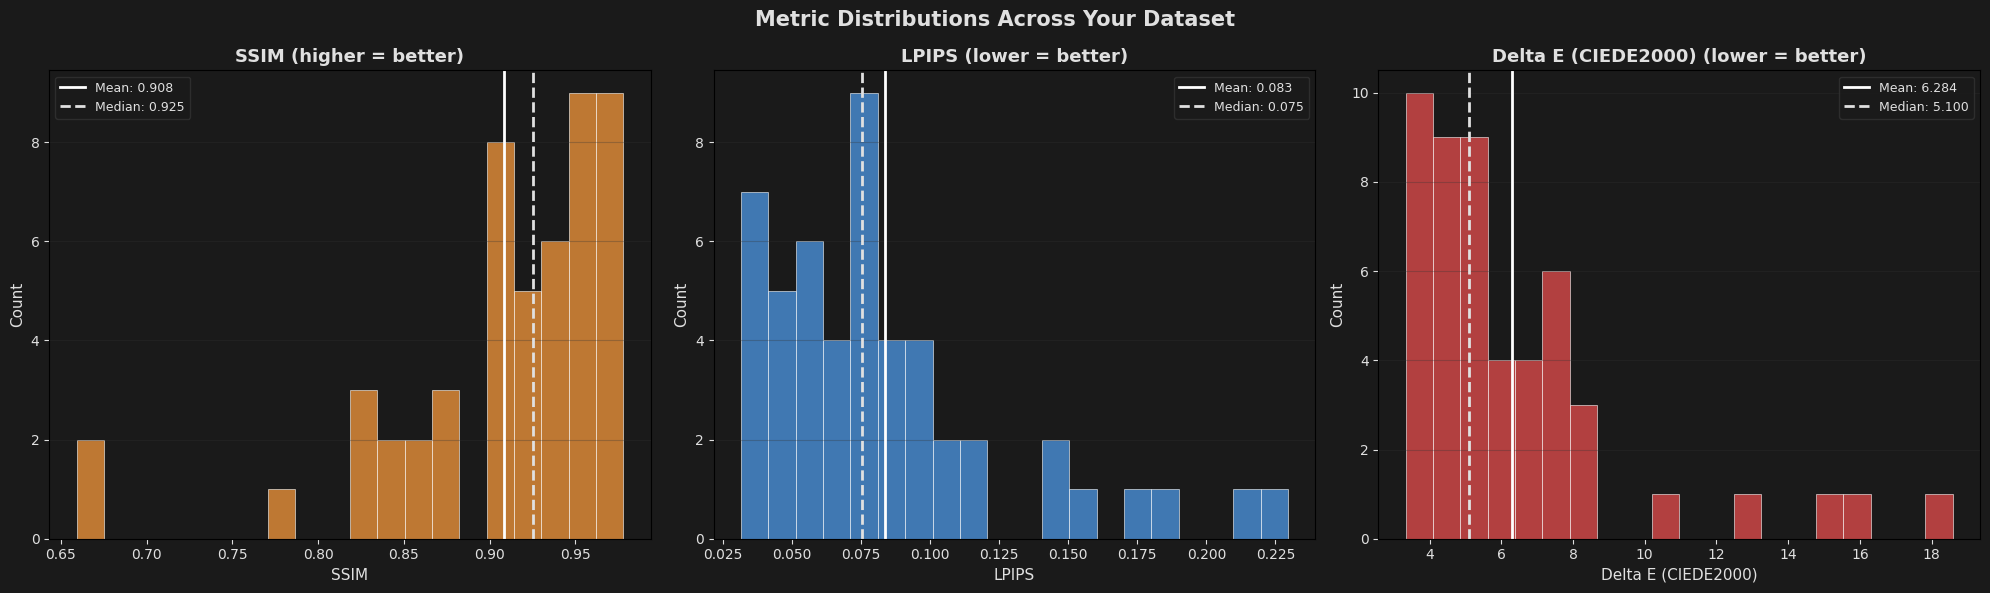

In [7]:
# Distribution plots
PALETTE = {'bg': '#1A1A1A', 'text': '#E0E0E0', 'grid': '#333333',
           'warm': '#E8913A', 'cool': '#4A90D9', 'accent': '#D94A4A'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=PALETTE['bg'])

for ax, (vals, name, better, color) in zip(axes, [
    (ssim_vals, 'SSIM', 'higher', PALETTE['warm']),
    (lpips_vals, 'LPIPS', 'lower', PALETTE['cool']),
    (de_vals, 'Delta E (CIEDE2000)', 'lower', PALETTE['accent']),
]):
    ax.set_facecolor(PALETTE['bg'])
    ax.hist(vals, bins=20, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(np.mean(vals), color='white', linewidth=2, linestyle='-',
               label=f'Mean: {np.mean(vals):.3f}')
    ax.axvline(np.median(vals), color=PALETTE['text'], linewidth=2, linestyle='--',
               label=f'Median: {np.median(vals):.3f}')

    ax.set_title(f'{name} ({better} = better)', color=PALETTE['text'],
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(name, color=PALETTE['text'], fontsize=11)
    ax.set_ylabel('Count', color=PALETTE['text'], fontsize=11)
    ax.tick_params(colors=PALETTE['text'])
    ax.grid(axis='y', color=PALETTE['grid'], alpha=0.3)
    ax.legend(facecolor=PALETTE['bg'], edgecolor=PALETTE['grid'],
              labelcolor=PALETTE['text'], fontsize=9)

plt.suptitle('Metric Distributions Across Your Dataset', color=PALETTE['text'],
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Best and Worst Matches

Visual inspection of where the pipeline succeeds and fails. The worst cases tell us what to fix next.

In [8]:
# Best and worst visual comparison
# Sort by SSIM (our primary structural metric)
sorted_metrics = sorted(all_metrics, key=lambda x: x['ssim'])

# Show 4 worst and 4 best
fig, axes = plt.subplots(4, 3, figsize=(18, 24), facecolor=PALETTE['bg'])
fig.suptitle('WORST MATCHES (lowest SSIM)', color=PALETTE['accent'],
             fontsize=16, fontweight='bold', y=0.98)

for row, m in enumerate(sorted_metrics[:4]):
    raw_f = m['image']
    edited_f = [e for r, e in pairs if r == raw_f][0]

    raw_img = resize_for_sam(Image.open(os.path.join(RAW_DIR, raw_f)).convert('RGB'))
    result, _, _ = auto_style_image(raw_img, image_id=raw_f)
    target = Image.open(os.path.join(EDITED_DIR, edited_f)).convert('RGB')

    for ax in axes[row]:
        ax.set_facecolor(PALETTE['bg'])

    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f'Raw: {raw_f}', color=PALETTE['text'], fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(result)
    axes[row, 1].set_title(
        f"Pipeline (SSIM={m['ssim']:.3f}, dE={m['delta_e']:.1f})\n"
        f"Regions: {', '.join(m['regions'])}",
        color=PALETTE['text'], fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(target)
    axes[row, 2].set_title(f'Your Edit: {edited_f}', color=PALETTE['text'], fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

# Best matches
fig, axes = plt.subplots(4, 3, figsize=(18, 24), facecolor=PALETTE['bg'])
fig.suptitle('BEST MATCHES (highest SSIM)', color=PALETTE['warm'],
             fontsize=16, fontweight='bold', y=0.98)

for row, m in enumerate(sorted_metrics[-4:]):
    raw_f = m['image']
    edited_f = [e for r, e in pairs if r == raw_f][0]

    raw_img = resize_for_sam(Image.open(os.path.join(RAW_DIR, raw_f)).convert('RGB'))
    result, _, _ = auto_style_image(raw_img, image_id=raw_f)
    target = Image.open(os.path.join(EDITED_DIR, edited_f)).convert('RGB')

    for ax in axes[row]:
        ax.set_facecolor(PALETTE['bg'])

    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f'Raw: {raw_f}', color=PALETTE['text'], fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(result)
    axes[row, 1].set_title(
        f"Pipeline (SSIM={m['ssim']:.3f}, dE={m['delta_e']:.1f})\n"
        f"Regions: {', '.join(m['regions'])}",
        color=PALETTE['text'], fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(target)
    axes[row, 2].set_title(f'Your Edit: {edited_f}', color=PALETTE['text'], fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Metric Correlation: Which Metric Tells Us What?

SSIM, LPIPS, and Delta E measure different things. If they disagree on which images are "worst," that tells us whether the problem is structural (wrong brightness/contrast) or chromatic (wrong colors).

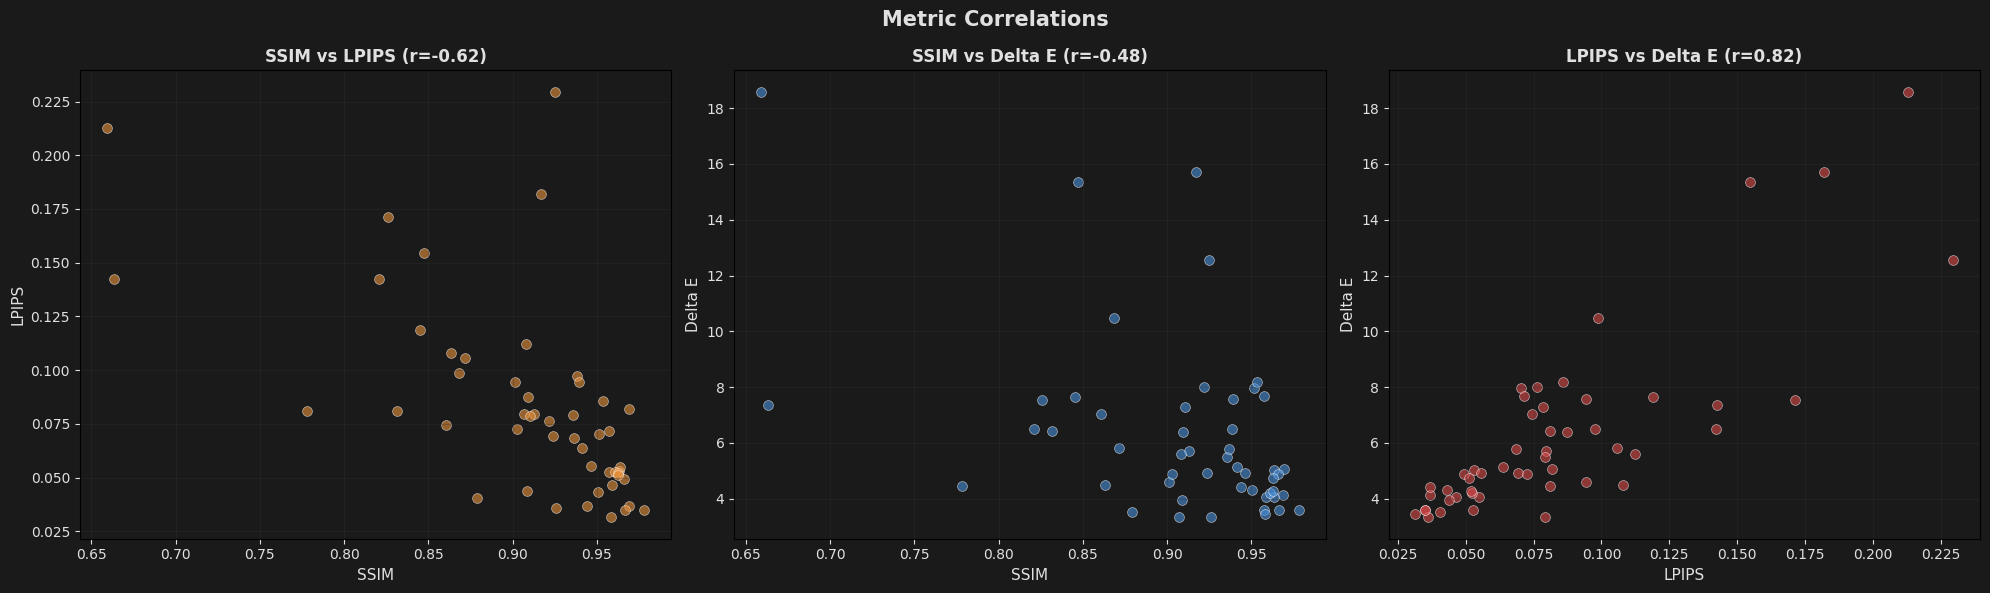

Correlation insights:
  SSIM and LPIPS disagree - some images look structurally OK but perceptually off
  SSIM and Delta E diverge - some images have correct colors but wrong structure (or vice versa)


In [9]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=PALETTE['bg'])

pairs_to_plot = [
    (ssim_vals, lpips_vals, 'SSIM', 'LPIPS', PALETTE['warm']),
    (ssim_vals, de_vals, 'SSIM', 'Delta E', PALETTE['cool']),
    (lpips_vals, de_vals, 'LPIPS', 'Delta E', PALETTE['accent']),
]

for ax, (x, y, xname, yname, color) in zip(axes, pairs_to_plot):
    ax.set_facecolor(PALETTE['bg'])
    ax.scatter(x, y, c=color, alpha=0.6, edgecolors='white', linewidth=0.5, s=50)

    # Correlation coefficient
    corr = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{xname} vs {yname} (r={corr:.2f})', color=PALETTE['text'],
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(xname, color=PALETTE['text'], fontsize=11)
    ax.set_ylabel(yname, color=PALETTE['text'], fontsize=11)
    ax.tick_params(colors=PALETTE['text'])
    ax.grid(True, color=PALETTE['grid'], alpha=0.3)

plt.suptitle('Metric Correlations', color=PALETTE['text'], fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretation
print("Correlation insights:")
ssim_lpips_r = np.corrcoef(ssim_vals, lpips_vals)[0, 1]
ssim_de_r = np.corrcoef(ssim_vals, de_vals)[0, 1]

if abs(ssim_lpips_r) > 0.7:
    print("  SSIM and LPIPS agree strongly - structural and perceptual quality are aligned")
else:
    print("  SSIM and LPIPS disagree - some images look structurally OK but perceptually off")

if abs(ssim_de_r) > 0.7:
    print("  SSIM and Delta E agree - structural issues are mostly color-driven")
else:
    print("  SSIM and Delta E diverge - some images have correct colors but wrong structure (or vice versa)")

## Strength Sensitivity: Is 0.6 the Right Dampener?

We test multiple strength values to find the sweet spot. Too low = under-editing, too high = overshooting.

Sweeping 8 strength values on 15 images...



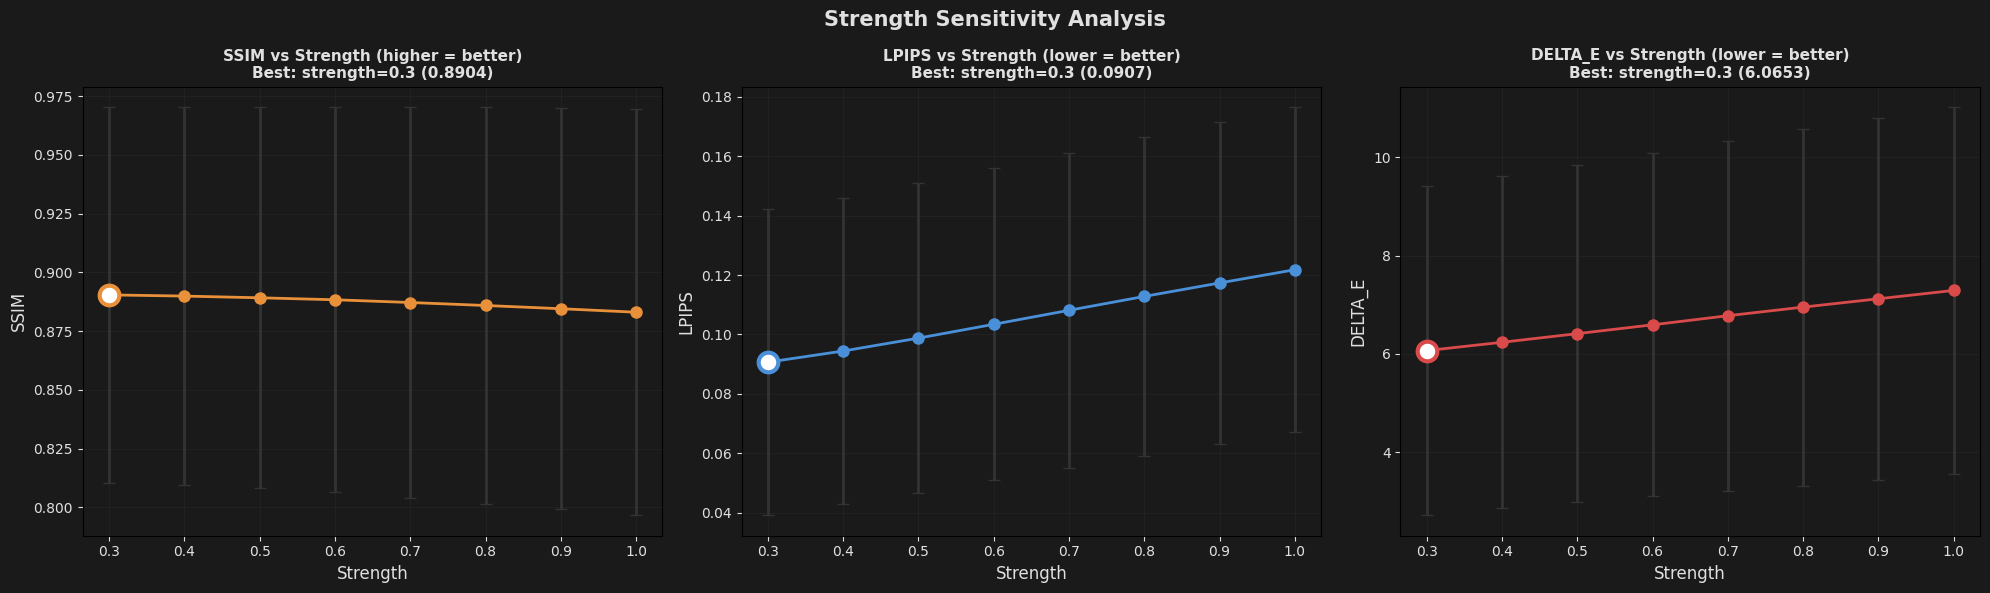


Optimal strength for SSIM: 0.3
Optimal strength for Delta E: 0.3

Both metrics agree: use strength=0.3
  Current default is 0.6 - consider updating to 0.3


In [10]:
# Strength sweep - test a range of strength values on a small subset to find the optimum
test_strengths = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sweep_sample = min(len(pairs), 15)  # small sample for speed
sweep_indices = np.linspace(0, len(pairs) - 1, sweep_sample, dtype=int)

strength_results = {s: [] for s in test_strengths}

print(f"Sweeping {len(test_strengths)} strength values on {sweep_sample} images...\n")

for idx in sweep_indices:
    raw_f, edited_f = pairs[idx]
    raw_img = resize_for_sam(Image.open(os.path.join(RAW_DIR, raw_f)).convert('RGB'))
    target_img = Image.open(os.path.join(EDITED_DIR, edited_f)).convert('RGB')

    # Segment once, reuse across all strengths
    segments = segment_and_label(raw_img, auto_generator, client,
                                  cache=mask_cache, image_id=raw_f)
    profile_edits = []
    seen = set()
    for seg in segments:
        label = seg['label']
        if label in seen:
            continue
        seen.add(label)
        if label in advanced_profile:
            profile_edits.append({'region': label, 'params': advanced_profile[label]})
        elif label in math_profile:
            rp = math_profile[label].get('parameters', {})
            if rp:
                profile_edits.append({'region': label, 'params': rp})

    for strength in test_strengths:
        result = apply_regional_edits(raw_img, segments, profile_edits, renderer, strength=strength)
        metrics = compute_metrics(result, target_img)
        strength_results[strength].append(metrics)

# Plot strength vs metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=PALETTE['bg'])

for ax, (metric_name, better, color) in zip(axes, [
    ('ssim', 'higher', PALETTE['warm']),
    ('lpips', 'lower', PALETTE['cool']),
    ('delta_e', 'lower', PALETTE['accent']),
]):
    ax.set_facecolor(PALETTE['bg'])
    means = [np.mean([m[metric_name] for m in strength_results[s]]) for s in test_strengths]
    stds = [np.std([m[metric_name] for m in strength_results[s]]) for s in test_strengths]

    ax.errorbar(test_strengths, means, yerr=stds, fmt='o-', color=color,
                capsize=4, linewidth=2, markersize=8, ecolor=PALETTE['grid'])

    # Highlight the best value
    if better == 'higher':
        best_idx = np.argmax(means)
    else:
        best_idx = np.argmin(means)
    ax.scatter([test_strengths[best_idx]], [means[best_idx]], s=200,
               color='white', zorder=5, edgecolors=color, linewidth=3)

    ax.set_xlabel('Strength', color=PALETTE['text'], fontsize=12)
    ax.set_ylabel(f'{metric_name.upper()}', color=PALETTE['text'], fontsize=12)
    ax.set_title(f'{metric_name.upper()} vs Strength ({better} = better)\n'
                 f'Best: strength={test_strengths[best_idx]} ({means[best_idx]:.4f})',
                 color=PALETTE['text'], fontsize=11, fontweight='bold')
    ax.tick_params(colors=PALETTE['text'])
    ax.grid(True, color=PALETTE['grid'], alpha=0.3)

plt.suptitle('Strength Sensitivity Analysis', color=PALETTE['text'],
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Recommendation
best_ssim_strength = test_strengths[np.argmax([np.mean([m['ssim'] for m in strength_results[s]]) for s in test_strengths])]
best_de_strength = test_strengths[np.argmin([np.mean([m['delta_e'] for m in strength_results[s]]) for s in test_strengths])]

print(f"\nOptimal strength for SSIM: {best_ssim_strength}")
print(f"Optimal strength for Delta E: {best_de_strength}")

if best_ssim_strength == best_de_strength:
    print(f"\nBoth metrics agree: use strength={best_ssim_strength}")
    if best_ssim_strength != 0.6:
        print(f"  Current default is 0.6 - consider updating to {best_ssim_strength}")
else:
    compromise = round((best_ssim_strength + best_de_strength) / 2, 1)
    print(f"\nMetrics disagree. Compromise: strength={compromise}")

## Per-Region Metric Breakdown

Do certain regions contribute more to the error than others? If the "subject" region is consistently off but "sky" is accurate, we know where to focus.

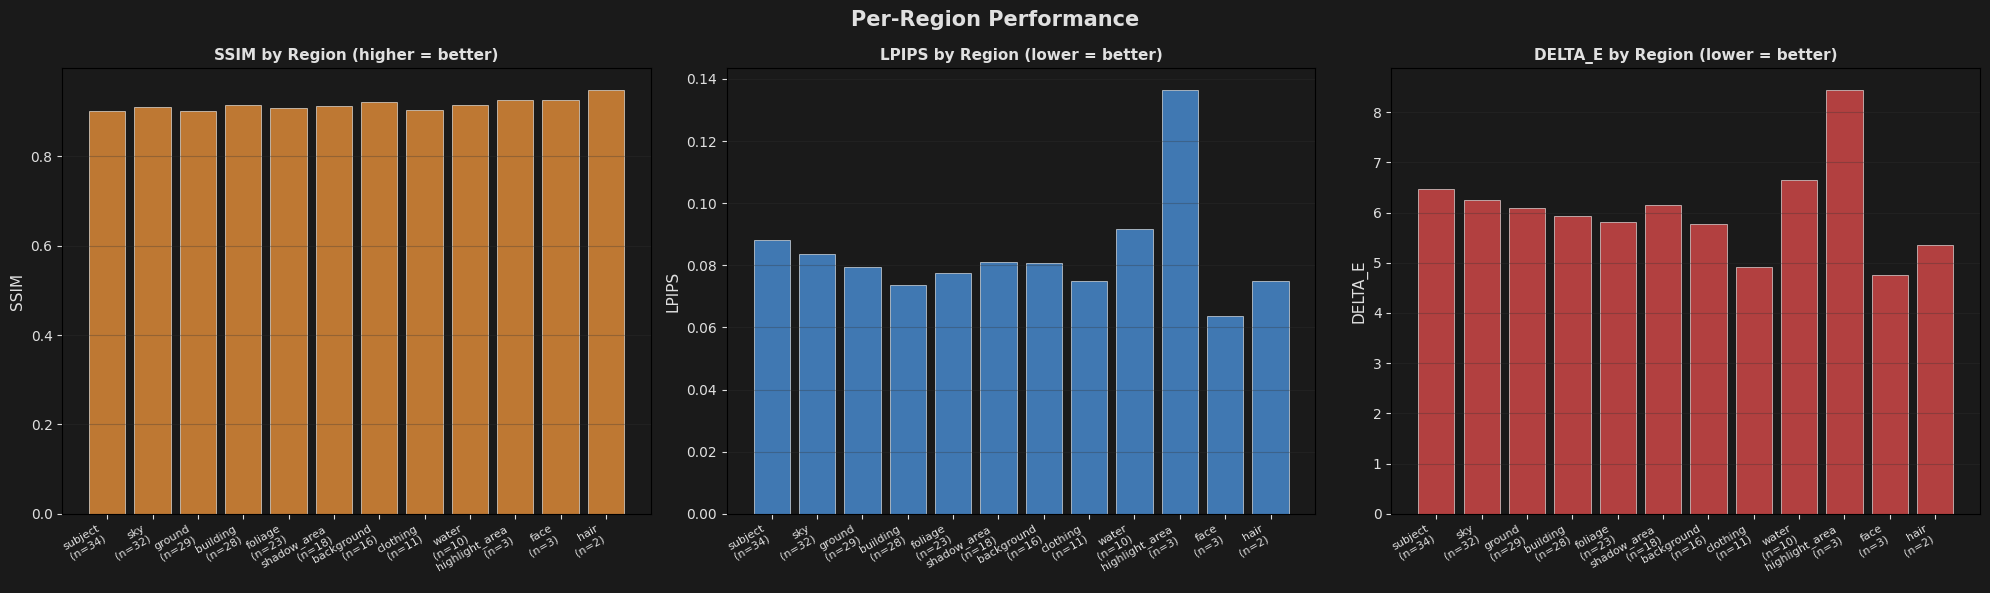


Region Performance Summary:
  subject            n=34   SSIM=0.902  dE=6.5  [good]
  sky                n=32   SSIM=0.910  dE=6.2  [good]
  ground             n=29   SSIM=0.902  dE=6.1  [good]
  building           n=28   SSIM=0.916  dE=5.9  [good]
  foliage            n=23   SSIM=0.907  dE=5.8  [good]
  shadow_area        n=18   SSIM=0.912  dE=6.2  [good]
  background         n=16   SSIM=0.921  dE=5.8  [good]
  clothing           n=11   SSIM=0.905  dE=4.9  [good]
  water              n=10   SSIM=0.915  dE=6.6  [good]
  highlight_area     n=3    SSIM=0.927  dE=8.4  [good]
  face               n=3    SSIM=0.926  dE=4.7  [good]
  hair               n=2    SSIM=0.950  dE=5.3  [good]


In [11]:
# Region analysis - group metrics by which regions were applied
region_metrics = defaultdict(lambda: {'ssim': [], 'lpips': [], 'delta_e': []})

for m in all_metrics:
    for region in m['regions']:
        region_metrics[region]['ssim'].append(m['ssim'])
        region_metrics[region]['lpips'].append(m['lpips'])
        region_metrics[region]['delta_e'].append(m['delta_e'])

if region_metrics:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=PALETTE['bg'])
    region_names = sorted(region_metrics.keys(),
                          key=lambda r: len(region_metrics[r]['ssim']), reverse=True)

    for ax, (metric, better, color) in zip(axes, [
        ('ssim', 'higher', PALETTE['warm']),
        ('lpips', 'lower', PALETTE['cool']),
        ('delta_e', 'lower', PALETTE['accent']),
    ]):
        ax.set_facecolor(PALETTE['bg'])
        means = [np.mean(region_metrics[r][metric]) for r in region_names]
        counts = [len(region_metrics[r][metric]) for r in region_names]

        bars = ax.bar(range(len(region_names)), means, color=color, alpha=0.8,
                      edgecolor='white', linewidth=0.5)
        ax.set_xticks(range(len(region_names)))
        ax.set_xticklabels([f"{r}\n(n={c})" for r, c in zip(region_names, counts)],
                           rotation=30, ha='right', color=PALETTE['text'], fontsize=8)
        ax.set_ylabel(metric.upper(), color=PALETTE['text'], fontsize=11)
        ax.set_title(f'{metric.upper()} by Region ({better} = better)',
                     color=PALETTE['text'], fontsize=11, fontweight='bold')
        ax.tick_params(colors=PALETTE['text'])
        ax.grid(axis='y', color=PALETTE['grid'], alpha=0.3)

    plt.suptitle('Per-Region Performance', color=PALETTE['text'],
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Find problematic regions
    print("\nRegion Performance Summary:")
    for r in region_names:
        n = len(region_metrics[r]['ssim'])
        avg_ssim = np.mean(region_metrics[r]['ssim'])
        avg_de = np.mean(region_metrics[r]['delta_e'])
        status = "good" if avg_ssim > 0.80 else "needs work" if avg_ssim > 0.70 else "problematic"
        print(f"  {r:<18} n={n:<4} SSIM={avg_ssim:.3f}  dE={avg_de:.1f}  [{status}]")

## Summary and Next Steps

The numbers above tell us:
1. **Overall quality** - are we in the ballpark or far off?
2. **Optimal strength** - should we tune up or down from 0.6?
3. **Weak regions** - which semantic regions need better profiles?
4. **Correlation** - are our problems structural (brightness/contrast) or chromatic (color)?

After reviewing, the main levers we can pull:
- Adjust `strength` in `shared.py` based on the sweep results
- Recalibrate tone curve extraction scaling if curves are too flat
- Add scene-type-specific strength values (night scenes might need different dampening than daylight)
- Improve the math profile extraction for underperforming regions